# Minutes landscape — participation and rotation (population)

*Read-only informative artifact. This notebook characterises the minutes /
participation landscape so a human can decide what a well-defined unit of
analysis is. It produces no gate decisions and no PROCEED/STOP verdict.*

## Questions a manager asks about minutes

- **Who plays full matches, and who gets rotated or subbed?** When I pick a
  player, how likely are they to actually go the distance?
- **How often does a typical player in each position actually start?** A
  "nailed" starter and a rotation risk are not the same asset, and the
  difference is structural by position.
- **What does rotation risk look like position by position?** How much of each
  position's appearances are secure, full-match minutes versus cameos and
  partial outings?

Everything below is **season-pooled** over the study range, on the
**participation** population (`minutes > 0` — the player actually featured).
This notebook describes the minutes distribution itself; whether a 60-minute
performance boundary separates two scoring regimes is the subject of
`population_boundary.ipynb`, and the rho-distortion question is framed in
`scope_sensitivity.ipynb`.

## Setup

Load the mart, restrict to the **whole season** (GW 1 to the latest completed
GW) and to the **participation** population (`minutes > 0`), and build position
cohorts.

The population is everyone who **actually featured**: available players with
`minutes > 0`. This is a **participation** filter (the player appeared), **not
a performance gate**. `minutes` can be NULL for some rows (blank-gameweek
rows); `minutes > 0` naturally excludes those (NULL comparisons are False).

This notebook deliberately **does not** impose the 60-minute boundary — it is
the layer that *describes* minutes so that boundary can be characterised
elsewhere. Baking it in here would pre-judge the very landscape we are meant to
map.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.distribution import (
    compute_distribution_stats,
    compare_cohorts,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

# Descriptive characterisation uses the WHOLE season: GW 1 to the latest
# completed GW. No early-GW lower bound (that was a predictive-evaluation
# choice in the older EDA-1 record, not relevant here).
STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

POSITIONS = ["GK", "DEF", "MID", "FWD"]
mart = _result.mart

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

# Analytical population: PARTICIPATION filter, not a performance gate.
# minutes > 0 naturally excludes NULL (blank-gameweek) rows.
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()

cohorts = {pos: df[df.position == pos] for pos in POSITIONS}

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0 (participation, not a performance gate), n = {len(df):,} player-gameweeks")
for pos in POSITIONS:
    print(f"  {pos}: {len(cohorts[pos]):>6,}")

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0 (participation, not a performance gate), n = 11,361 player-gameweeks
  GK:    757
  DEF:  3,904
  MID:  5,288
  FWD:  1,412


## (a) Minutes distribution by position

**What we measure** — the full univariate shape of `minutes` within each
position cohort (count, mean, median, std, percentiles, skew) via
`compare_cohorts`, plus a by-position histogram of `minutes`.

*Stat glossary for this table:* **mean** — arithmetic average, pulled up by rare hauls; **median** — middle value, the robust "typical" return; **std** — typical distance from the mean in points, sensitive to outliers; **IQR (p75−p25)** — spread of the middle 50%, robust to skew; **p90/p99** — score exceeded by only 10%/1% of appearances (practical ceiling); **skew** — positive = long right tail of rare high scores.

**What it means** — this is the rotation/durability fingerprint of each
position. The median says how long a *typical* featured player stays on; the
lower percentiles expose how much of a position's appearances are cameos. The
histogram matters because the **shape** is bimodal — a wall of full-90 mass and
a separate hump of sub/cameo minutes — and that two-regime shape is exactly
what a single mean or median hides. For squad selection this is the difference
between a nailed asset and a bench-fodder gamble.

**What it doesn't mean** — these are **season-pooled** minutes across all
players and weeks in range, not any one player's reliability week-to-week
(that is a within-player, week-to-week question, out of scope here). Minutes also say nothing about
scoring: a full 90 can still blank, and a 20-minute cameo can return. This
section describes *exposure*, not *performance*, and imposes no 60-minute
boundary — `population_boundary.ipynb` characterises that.

**Guiding question (directive)** — *Determine how minutes distribute by
position — establish who plays full matches versus who is rotated or subbed.*

In [2]:
mins_by_pos = compare_cohorts(cohorts, value_col="minutes")
display(
    mins_by_pos[
        ["count", "mean", "median", "std", "p25", "p75", "p90", "p99", "min", "max", "skew"]
    ].round(2)
)

,count,mean,median,std,p25,p75,p90,p99,min,max,skew
cohort,,,,,,,,,,,
GK,757,90.350,90.000,12.500,90.000,90.000,90.000,180.000,4,180,3.180
DEF,3904,73.030,90.000,31.300,64.000,90.000,90.000,99.000,1,180,-0.930
MID,5288,60.390,73.000,32.900,27.000,90.000,90.000,90.000,1,180,-0.400
FWD,1412,53.620,64.000,33.980,19.000,87.000,90.000,90.000,1,180,-0.000


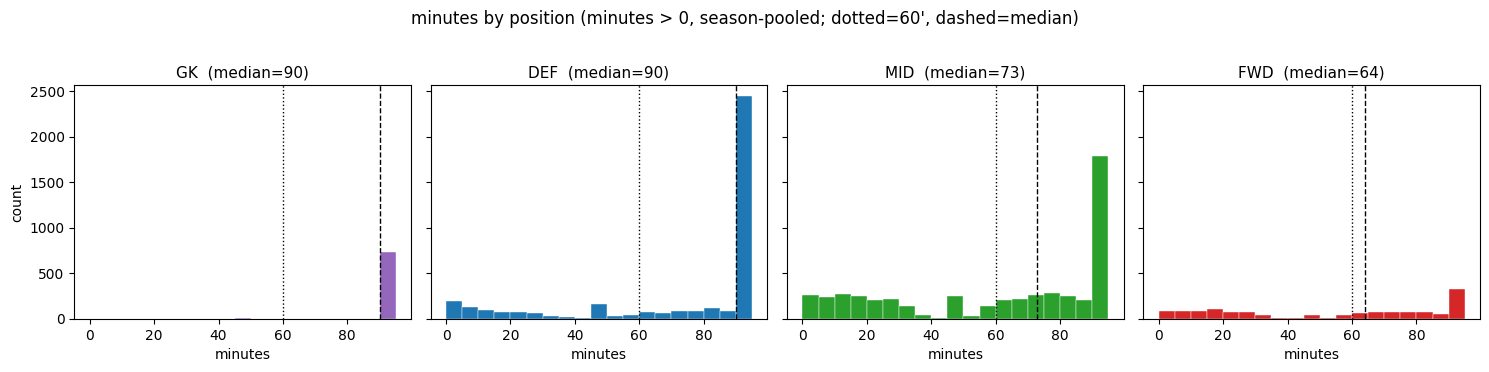

In [3]:
# The minutes distribution is bimodal -- a full-90 wall plus a cameo/sub hump --
# which a mean or median hides. Overlaid per-position histograms show the shape.
colours = {"GK": "#9467bd", "DEF": "#1f77b4", "MID": "#2ca02c", "FWD": "#d62728"}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
bins = range(0, 100, 5)
for ax, pos in zip(axes, POSITIONS):
    s = cohorts[pos]["minutes"].dropna().astype(float)
    ax.hist(s, bins=bins, color=colours[pos], edgecolor="white", linewidth=0.3)
    ax.axvline(60, color="black", linestyle=":", linewidth=1.0)
    ax.axvline(s.median(), color="black", linestyle="--", linewidth=1.0)
    ax.set_title(f"{pos}  (median={s.median():.0f})", fontsize=11)
    ax.set_xlabel("minutes")
axes[0].set_ylabel("count")
fig.suptitle("minutes by position (minutes > 0, season-pooled; dotted=60', dashed=median)", y=1.02)
plt.tight_layout()
plt.show()

## (b) Start rate by position

**What we measure** — for each position, the share of **featured**
player-gameweeks (`minutes > 0`) that were a **start**. The mart's `starts`
column is an integer (0 = came off the bench; >= 1 = started, and 2 on a
double-gameweek where the player started both fixtures); we read "started" as
`starts >= 1` and report the mean over the featured cohort.

**What it means** — this is the **nailedness / rotation-risk** read by
position. A high start rate means that when a player from this position
features, they almost always start (low rotation risk); a lower rate means a
meaningful slice of featured appearances are off-the-bench cameos. This is the
core transfer-confidence property: a nailed starter is a hold, a rotation risk
is a gamble.

**What it doesn't mean** — this is a **season-pooled** rate over the featured
population, not the probability that a *specific* player starts next week. It
mixes nailed starters and rotation options within each position. Because it is
conditioned on `minutes > 0`, it is the start rate *given the player featured*,
not the start rate over all squad members (benched-and-unused players are not
in this population). It says nothing about scoring.

**Guiding question (directive)** — *Establish each position's start rate,
given the player featured.*

In [4]:
# Start rate = fraction of featured GWs that were starts. `starts` is Int64
# (0 = bench appearance, >=1 = started; 2 = started both DGW fixtures).
# Read "started" as starts >= 1. NULL starts (none expected in featured rows)
# are treated as not-started via fillna(0).
start_rate = (
    df.assign(started=(df["starts"].fillna(0) >= 1))
    .groupby("position")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "start_rate_%": round(g["started"].mean() * 100, 1),
        "bench_appearance_%": round((~g["started"]).mean() * 100, 1),
    }))
    .reset_index()
)
display(start_rate)

,position,n,start_rate_%,bench_appearance_%
0,DEF,3904.000,80.700,19.300
1,FWD,1412.000,58.300,41.700
2,GK,757.000,99.100,0.900
3,MID,5288.000,67.200,32.800


## (c) Minutes-band composition by position

**What we measure** — for each position, the share of featured player-gameweeks
falling into four **minutes bands**: `1-29` (cameo), `30-59` (partial),
`60-89` (near-full), and `90` (full). Computed inline as proportions within
each cohort.

**What it means** — this decomposes the rotation picture into *how much of each
position's appearances are secure minutes*. The combined `60-89` + `90` share
is the slice that survives a 60-minute filter — the "genuine outing" mass — and
the `1-29` + `30-59` share is what such a filter would discard. For squad
planning, a position dominated by full-90 mass is where minutes are
dependable; one with heavy cameo mass carries structural rotation risk even
among players who feature.

**What it doesn't mean** — these are **season-pooled** band shares, not a
forecast of next week's minutes for any player. The band edges (30 / 60 / 90)
are descriptive conveniences, not validated thresholds — the `60` edge is shown
because it is the boundary `population_boundary.ipynb` characterises, **not**
because it is imposed here as a gate. Band membership says nothing about points
returned within the band.

**Guiding question (directive)** — *Quantify each position's secure-minutes
(60+) share versus its cameo / partial share.*

In [5]:
# Minutes-band composition within each position cohort. Edges 30 / 60 / 90 are
# descriptive; the 60 edge is the boundary characterised in
# population_boundary.ipynb, NOT imposed here as a gate.
BANDS = ["1-29", "30-59", "60-89", "90"]

def _band(mn):
    if mn < 30:
        return "1-29"
    if mn < 60:
        return "30-59"
    if mn < 90:
        return "60-89"
    return "90"

rows = []
for pos in POSITIONS:
    c = cohorts[pos]
    bands = c["minutes"].dropna().astype(int).map(_band)
    share = bands.value_counts(normalize=True).reindex(BANDS).fillna(0.0) * 100
    row = {"position": pos, "n": len(bands)}
    for b in BANDS:
        row[f"{b}_%"] = round(float(share[b]), 1)
    row["secure_60+_%"] = round(float(share["60-89"] + share["90"]), 1)
    rows.append(row)
band_composition = pd.DataFrame(rows)
display(band_composition)

,position,n,1-29_%,30-59_%,60-89_%,90_%,secure_60+_%
0,GK,757,0.500,0.800,0.500,98.200,98.700
1,DEF,3904,16.000,7.400,13.100,63.600,76.700
2,MID,5288,27.300,11.400,26.800,34.500,61.300
3,FWD,1412,36.200,10.300,30.000,23.500,53.500


## What the minutes landscape looks like

Plain-language summary of the descriptive picture (not a verdict):

- The minutes distribution is **bimodal** for outfield positions — a full-90
  wall plus a separate cameo/sub hump — which is why the histogram, not the
  mean, carries the shape. Median minutes fall up the pitch: **GK 90, DEF 90,
  MID 73, FWD 64**. GK is almost entirely full-90 mass (mean 90.4); rotation in
  goal is binary (you play or you don't).
- **Start rate falls as you move up the pitch** — GK **99.1%**, DEF **80.7%**,
  MID **67.2%**, FWD **58.3%**. Keepers and defenders that feature almost always
  start; forwards carry the most bench-appearance mass (41.7%) — attacking
  rotation and impact-sub use show up here.
- **Secure-minutes (60+) share mirrors this** — GK **98.7%**, DEF **76.7%**,
  MID **61.3%**, FWD **53.5%**. A 60-minute filter would keep almost every GK
  appearance but discard nearly half of featured FWD appearances, which is where
  structural rotation risk concentrates.
- **DGW rows show up as a minutes p99 of 180** (two fixtures summed at one
  player-GW) — a mechanical doubling, not a 180-minute match; per-fixture
  treatment is the `fixture/` layer's job.

All figures are **whole-season**, season-pooled, over the **participation**
population (`minutes > 0` — the player featured — not a performance gate). This
notebook describes the minutes axis only. Whether the 60-minute mark separates
two scoring regimes is characterised in `population_boundary.ipynb`; whether
analytical conclusions shift across population scopes is answered (on full-season
data) in `scope_sensitivity.ipynb`; within-player minutes dynamics are deferred
to the `temporal/` layer.